/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_21520/313919437.py:39: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


✅ Connected to MQTT broker
📡 Received 400/400 samples
📦 Total collection time: 21.02 sec

──── IMU Sampling Timing Summary ────
Samples received: 400
Average sampling frequency: 18.90 Hz
Mean interval: 52.902 ms
Jitter (std): 20.000 ms
Min interval: 42.503 ms
Max interval: 107.400 ms


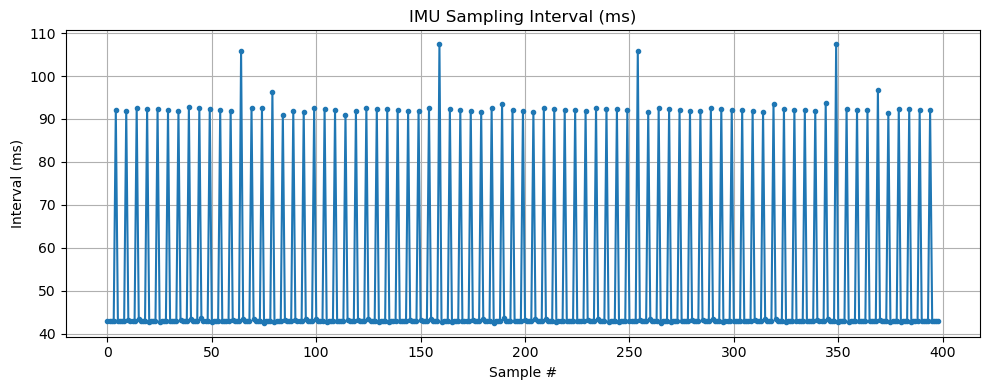

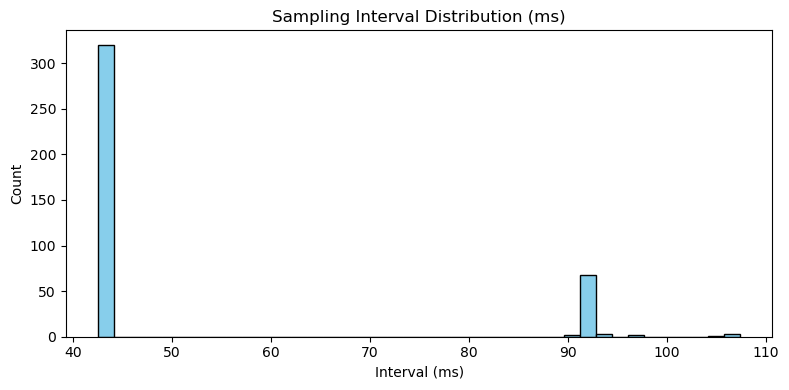

In [23]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import time

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
MAX_MESSAGES = 100    # collect this many MQTT messages

timestamps = []

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global timestamps
    payload = msg.payload.decode("utf-8").strip()

    # find all timestamp groups inside [[t,...],[t,...],...]
    found = re.findall(r"\[\s*([0-9]+)", payload)
    for t in found:
        timestamps.append(int(t))

    print(f"📡 Received {len(timestamps)}/{MAX_MESSAGES * 4} samples", end="\r")

    # stop after collecting enough messages
    if len(timestamps) >= MAX_MESSAGES * 4:
        client.disconnect()

# ─── MQTT Client ────────────────────────────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

start_time = time.time()
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_forever()
elapsed = time.time() - start_time

print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert timestamps to DataFrame ────────────────────────
df = pd.DataFrame({"t": sorted(timestamps)})

# handle wrap-around of micros() (~70 min)
df["dt"] = df["t"].diff()
df.loc[df["dt"] < 0, "dt"] += 2**32  # handle rollover

df = df.dropna().reset_index(drop=True)
df["dt_sec"] = df["dt"] / 1_000_000.0

avg_freq = 1 / df["dt_sec"].mean()
jitter_ms = df["dt_sec"].std() * 1000

print("\n──── IMU Sampling Timing Summary ────")
print(f"Samples received: {len(df)+1}")
print(f"Average sampling frequency: {avg_freq:.2f} Hz")
print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
print(f"Jitter (std): {jitter_ms:.3f} ms")
print(f"Min interval: {df['dt_sec'].min()*1000:.3f} ms")
print(f"Max interval: {df['dt_sec'].max()*1000:.3f} ms")

# ─── Visualization ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(df["dt_sec"] * 1000, marker='.')
plt.title("IMU Sampling Interval (ms)")
plt.xlabel("Sample #")
plt.ylabel("Interval (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["dt_sec"] * 1000, bins=40, color='skyblue', edgecolor='k')
plt.title("Sampling Interval Distribution (ms)")
plt.xlabel("Interval (ms)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
